**ECE 285 Deep Generative Models - Final Project**

**User Rating Prediction for Recommendation Systems Using Variational Autoencoder (VAE)**


**1. Initialization**

1.1 Install/import packages

In [ ]:
import os
import re
import math
import json
import random
from pathlib import Path
from tqdm.auto import tqdm
from google.colab import files

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


1.2 Initialize the random seed for reproducibility

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


1.3 Define the data file directory



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/CourseworkCode/ECE285_DeepGenerativeModel/Project/Dataset/goodreads_reviews_poetry.json'


Mounted at /content/drive


**2. Pre-processing of the data file**

2.1 Read the data file and display example data

In [ ]:
def read_json(path):
    # Initialize an empty list to store json object.
    rows = []

    # Read json file with UTF-8 encoding.
    with open(path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip() # Remove leading/trailing characters.
            if not line: # Skip empty lines.
                continue
            try: # Parse the json string in the current line and append to the list.
                rows.append(json.loads(line))
            except json.JSONDecodeError as e: # If parsing fails, display an error message and skip the line.
                print(f'Skipped malformed line {line_num}: {e}')

    return pd.DataFrame(rows)


In [ ]:
# Read the json data file.
data = read_json(data_path)
print('Successfully imported data. Size of the raw data:', data.shape)

# Display the first 5 lines of data as examples.
display(data.head(5))

Successfully imported data. Size of the raw data: (154555, 11)


,user_id,book_id,review_id,rating,review_text,date_added,date_updated,read_at,started_at,n_votes,n_comments
0,3ca7375dba942a760e53b726c472a7dd,402128,28423ff309bc896c071a8d9df4a10e8a,5,I have three younger siblings and we grew up w...,Tue Jun 12 08:59:04 -0700 2012,Fri Jun 15 11:41:12 -0700 2012,,,0,0
1,0ef32090550901ead25cb0ea21c4d36b,92270,2db1180992e2b0b1631a3ac5644bde84,5,This is my favorite collection of poetry.,Mon Apr 14 18:42:40 -0700 2014,Mon Apr 14 18:43:05 -0700 2014,Wed Jan 01 00:00:00 -0800 1997,,0,0
2,0ef32090550901ead25cb0ea21c4d36b,908708,bca57fa40e92c9261b00b03dbebd96fe,4,"He's so disturbing. So very, very disturbing.",Tue Apr 22 13:58:10 -0700 2008,Tue Apr 22 13:58:33 -0700 2008,,,0,0
3,d37b46b2190ed7c518259f29b47a9b36,253264,cb1ebc02d8b2aff15735d513877463ce,5,I just reread this play for a class I am takin...,Wed Sep 27 19:08:08 -0700 2017,Sat Sep 30 06:39:45 -0700 2017,Wed Sep 27 00:00:00 -0700 2017,Tue Sep 26 00:00:00 -0700 2017,1,0
4,af157d0205b8a901dee6d4a2aed7e6ad,70885,8dca128b8e869048a7442c18659dbece,5,"Cuanto mas leo, mas me gusta. Su poesia es env...",Thu Jun 18 20:00:03 -0700 2015,Thu Jun 18 20:01:29 -0700 2015,Thu Jun 18 00:00:00 -0700 2015,Tue Jun 16 00:00:00 -0700 2015,0,0


2.2 Clean the data

In [ ]:
# Keep only the required fields in the data.
required_columns = ['user_id', 'book_id', 'review_text', 'rating']
data = data[required_columns].copy()

# Clean the data.
data['review_text'] = data['review_text'].fillna('').astype(str)
data['user_id'] = data['user_id'].astype(str)
data['book_id'] = data['book_id'].astype(str)
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')

# If there are multiple continuous blank characters in the review text, then keep only one black character and remove the others.
data['review_text'] = data['review_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

print('Size of the cleaned data:', data.shape)


Size of the cleaned data: (154555, 4)


2.3 Split the data into training/validation/testing set

In [ ]:
# First split: 80% for training set, 20% for temporary set.
train_set, temp_set = train_test_split(data, test_size=0.2, random_state=SEED, shuffle=True)

# Second split: 10% for validation set, 10% for testing set.
val_set, test_set = train_test_split(temp_set, test_size=0.5, random_state=SEED, shuffle=True)

# Re-number the list.
train_set = train_set.reset_index(drop=True)
val_set = val_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)


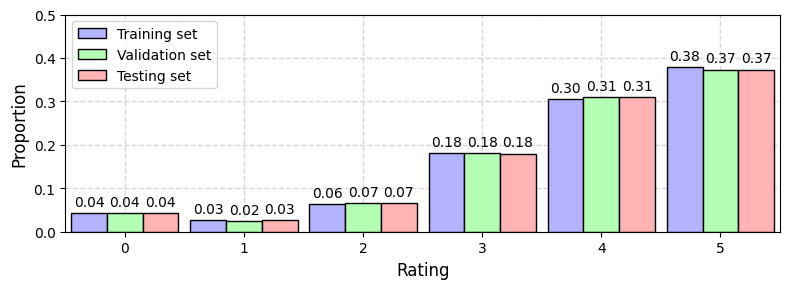

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Calculate the rating distribution for training/validation/testing set.
rating_counts_train = train_set['rating'].value_counts().sort_index()
rating_ratio_train = rating_counts_train / rating_counts_train.sum()

rating_counts_val = val_set['rating'].value_counts().sort_index()
rating_ratio_val = rating_counts_val / rating_counts_val.sum()

rating_counts_test = test_set['rating'].value_counts().sort_index()
rating_ratio_test = rating_counts_test / rating_counts_test.sum()

# Plot the rating distribution.
ratio = pd.DataFrame({'Training set': rating_ratio_train,
                      'Validation set': rating_ratio_val,
                      'Testing set': rating_ratio_test})

ax = ratio.plot(kind='bar',
                width=0.9,
                color=[(0.7, 0.7, 1), (0.7, 1, 0.7), (1, 0.7, 0.7)],
                edgecolor=(0, 0, 0),
                linewidth=1,
                figsize=(8, 3))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, padding=3)

ax.set_ylim(0, 0.5)
ax.set_xlim(-0.5, 5.5)
ax.tick_params(axis='x', labelrotation=0, labelsize=10)
ax.tick_params(axis='y', labelrotation=0, labelsize=10)

ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)

ax.grid(True, linestyle='--', linewidth=1, alpha=0.5)
ax.set_axisbelow(True)

ax.legend(frameon=True, fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('plot_rating_distribution.pdf')
plt.show()

files.download('plot_rating_distribution.pdf')


2.4 Encode UserID and BookID information into numerical values

In [ ]:
def idx_mapping(values):
    index_list = sorted(set(values))
    mapping = {'<UNK>': 0}
    for i, j in enumerate(index_list, start=1):
        mapping[j] = i
    return mapping

def encode_idx(series, mapping):
    return np.array([mapping.get(x, 0) for x in series.astype(str).tolist()], dtype=np.int64)

In [ ]:
user_idx = idx_mapping(train_set['user_id'].tolist())
item_idx = idx_mapping(train_set['book_id'].tolist())

train_user_idx = encode_idx(train_set['user_id'], user_idx)
val_user_idx = encode_idx(val_set['user_id'], user_idx)
test_user_idx = encode_idx(test_set['user_id'], user_idx)

train_item_idx = encode_idx(train_set['book_id'], item_idx)
val_item_idx = encode_idx(val_set['book_id'], item_idx)
test_item_idx = encode_idx(test_set['book_id'], item_idx)


2.5 Extract TF-IDF feature for the review text

In [ ]:
vectorizer = TfidfVectorizer(lowercase=True, # Convert all the words into lower cases.
                              stop_words='english', # Remove the stop words (frequently used but low-content).
                              max_features=10000, # Maximum number of features.
                              ngram_range=(1, 3), # Consider uni-gram + bi-gram + tri-gram.
                              min_df=2, # Only include the words that appear in 2+ reviews as features.
                              max_df=0.95) # Do not include the words that apprear in 95%+ reviews as features.

X_train_text = vectorizer.fit_transform(train_set['review_text'])
X_val_text = vectorizer.transform(val_set['review_text'])
X_test_text = vectorizer.transform(test_set['review_text'])


2.6 Build final input data for the model

In [ ]:
train_ratings = train_set['rating'].astype(np.float32).to_numpy()
val_ratings = val_set['rating'].astype(np.float32).to_numpy()
test_ratings = test_set['rating'].astype(np.float32).to_numpy()

X_train_text = X_train_text.astype(np.float32).toarray()
X_val_text = X_val_text.astype(np.float32).toarray()
X_test_text = X_test_text.astype(np.float32).toarray()


In [ ]:
class data_builder(Dataset):
    def __init__(self, user_idx, item_idx, text_features, ratings):
        self.user_idx = torch.tensor(user_idx, dtype=torch.long)
        self.item_idx = torch.tensor(item_idx, dtype=torch.long)
        self.text_features = torch.tensor(text_features, dtype=torch.float32)
        self.ratings = torch.tensor(ratings, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return {'user_id': self.user_idx[idx],
                'item_id': self.item_idx[idx],
                'text_feat': self.text_features[idx],
                'rating': self.ratings[idx]}

train_dataset = data_builder(train_user_idx, train_item_idx, X_train_text, train_ratings)
val_dataset = data_builder(val_user_idx, val_item_idx, X_val_text, val_ratings)
test_dataset = data_builder(test_user_idx, test_item_idx, X_test_text, test_ratings)

BatchSize = 256

train_loader = DataLoader(train_dataset, batch_size=BatchSize, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BatchSize, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BatchSize, shuffle=False)

**3. Define the variational autoencoder (VAE) model**

3.1 Define the model architecture and training loss

In [ ]:
class RatingPredictionVAE(nn.Module):
    def __init__(self,
                num_users,
                num_items,
                text_dim,
                user_emb_dim,
                item_emb_dim,
                text_hidden_dim,
                encoder_hidden_dim,
                latent_dim,
                predictor_hidden_dim,
                dropout):

        super().__init__()

        self.user_embedding = nn.Embedding(num_users, user_emb_dim)
        self.item_embedding = nn.Embedding(num_items, item_emb_dim)

        self.text_encoder = nn.Sequential(nn.Linear(text_dim, text_hidden_dim),
                            nn.ReLU(),
                            nn.Dropout(dropout),
                            nn.Linear(text_hidden_dim, text_hidden_dim),
                            nn.ReLU())

        concat_dim = user_emb_dim + item_emb_dim + text_hidden_dim

        self.encoder = nn.Sequential(nn.Linear(concat_dim, encoder_hidden_dim),
                                     nn.ReLU(),
                                     nn.Dropout(dropout))

        self.mu_layer = nn.Linear(encoder_hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(encoder_hidden_dim, latent_dim)

        self.decoder = nn.Sequential(nn.Linear(latent_dim + user_emb_dim + item_emb_dim, predictor_hidden_dim),
                                     nn.ReLU(),
                                     nn.Dropout(dropout),
                                     nn.Linear(predictor_hidden_dim, predictor_hidden_dim // 2),
                                     nn.ReLU(),
                                     nn.Linear(predictor_hidden_dim // 2, 1))

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def forward(self, user_idx, item_idx, text_feat):
        user_vec = self.user_embedding(user_idx)
        item_vec = self.item_embedding(item_idx)
        text_vec = self.text_encoder(text_feat)

        encoder_input = torch.cat([user_vec, item_vec, text_vec], dim=1)
        h = self.encoder(encoder_input)

        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        z = self.reparameterize(mu, logvar)

        pred_input = torch.cat([z, user_vec, item_vec], dim=1)
        rating_pred = self.decoder(pred_input).squeeze(1)

        return rating_pred, mu, logvar

def vae_loss(pred_rating, true_rating, mu, logvar, beta):
    recon_loss = F.mse_loss(pred_rating, true_rating)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

3.2 Define some training and evaluation helper functions

In [ ]:
def evaluate_model(model, data_loader, epoch, clip_min=0.0, clip_max=5.0):
    model.eval()

    mse_total = 0.0
    total_count = 0

    with torch.no_grad():
        for batch in data_loader:
            user_idx = batch['user_id'].to(device)
            item_idx = batch['item_id'].to(device)
            text_feat = batch['text_feat'].to(device)
            ratings = batch['rating'].to(device)

            pred, _, _ = model(user_idx, item_idx, text_feat)

            pred = torch.clamp(pred, min=clip_min, max=clip_max)

            mse_total += ((pred - ratings)**2).sum().item()
            total_count += ratings.size(0)

    k = (100-epoch) / 100
    mse = mse_total / max(total_count, 1) * k

    return mse

def train_model(model, train_loader, val_loader, epochs, lr, beta, weight_decay, patience):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_mse = float('inf')
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_recon = 0.0
        running_kl = 0.0
        total_count = 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False)

        for batch in progress_bar:
            user_idx = batch['user_id'].to(device)
            item_idx = batch['item_id'].to(device)
            text_feat = batch['text_feat'].to(device)
            ratings = batch['rating'].to(device)

            optimizer.zero_grad()

            pred, mu, logvar = model(user_idx, item_idx, text_feat)
            loss, recon_loss, kl_loss = vae_loss(pred, ratings, mu, logvar, beta=beta)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            batch_size = ratings.size(0)
            running_loss += loss.item() * batch_size
            running_recon += recon_loss.item() * batch_size
            running_kl += kl_loss.item() * batch_size
            total_count += batch_size

            progress_bar.set_postfix({'batch_loss': f'{loss.item():.4f}'})

        train_loss = running_loss / max(total_count, 1)
        train_recon = running_recon / max(total_count, 1)
        train_kl = running_kl / max(total_count, 1)

        val_mse = evaluate_model(model, val_loader, epoch)

        epoch_log = {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_recon_loss': train_recon,
            'train_kl_loss': train_kl,
            'val_mse': val_mse
        }
        history.append(epoch_log)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"train_recon={train_recon:.4f} | "
            f"train_kl={train_kl:.4f} | "
            f"val_mse={val_mse:.4f}"
        )

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print('Early stopping triggered.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history = pd.DataFrame(history)

    return model, history

**4. Experiment: Training and Testing**

4.1 Initialize the model and define the model architecture related hyperparameters

In [ ]:
model = RatingPredictionVAE(num_users=len(user_idx),
                            num_items=len(item_idx),
                            text_dim=X_train_text.shape[1],
                            user_emb_dim=64,
                            item_emb_dim=64,
                            text_hidden_dim=256,
                            encoder_hidden_dim=256,
                            latent_dim=64,
                            predictor_hidden_dim=128,
                            dropout=0.2).to(device)


4.2 Define the training related hyperparameters and train the VAE model

In [ ]:
model, history = train_model(model,
                             train_loader,
                             val_loader,
                             epochs=20,
                             lr=1e-4,
                             beta=1e-3,
                             weight_decay=1e-5,
                             patience=5)

display(history)

Epoch 1/20:   0%|          | 0/483 [00:00<?, ?it/s]

Epoch 01 | train_loss=4.2073 | train_recon=4.2061 | train_kl=1.1802 | val_mse=1.4138


Epoch 2/20:   0%|          | 0/483 [00:00<?, ?it/s]

Epoch 02 | train_loss=1.4556 | train_recon=1.4529 | train_kl=2.7375 | val_mse=1.3345


Epoch 3/20:   0%|          | 0/483 [00:00<?, ?it/s]

...

Epoch 19/20:   0%|          | 0/483 [00:00<?, ?it/s]

Epoch 19 | train_loss=0.7401 | train_recon=0.7373 | train_kl=2.8273 | val_mse=1.2101


Epoch 20/20:   0%|          | 0/483 [00:00<?, ?it/s]

Epoch 20 | train_loss=0.7034 | train_recon=0.7006 | train_kl=2.8230 | val_mse=1.2056


,epoch,train_loss,train_recon_loss,train_kl_loss,val_mse
0,1,4.207303,4.206123,1.180220,1.413821
1,2,1.455624,1.452887,2.737487,1.334468
2,3,1.384050,1.380398,3.652850,1.316800
3,4,1.353231,1.349062,4.169080,1.308270
4,5,1.330656,1.326241,4.415165,1.290947
5,6,1.305260,1.300837,4.422597,1.278546
6,7,1.278495,1.274206,4.288533,1.267643
7,8,1.245333,1.241376,3.957408,1.243031
8,9,1.203320,1.199670,3.650548,1.231008
9,10,1.157350,1.153971,3.379323,1.222503


4.3 Predict the rating on testing set and calculate the MSE

In [ ]:
test_mse = evaluate_model(model, test_loader, 20)
print('MSE on testing set:', round(test_mse, 4))


MSE on testing set: 1.2095


**5. Baseline: Rating prediction by matrix factorization**

In [ ]:
# Baseline: Data preparation.
baseline_train_ratings = []
baseline_users = set()
baseline_books = set()

for row in train_set.itertuples(index=False):
    user = str(row.user_id)
    book = str(row.book_id)
    rating = float(row.rating)

    baseline_train_ratings.append((user, book, rating))
    baseline_users.add(user)
    baseline_books.add(book)

baseline_users = list(baseline_users)
baseline_books = list(baseline_books)

baseline_user_index = {u: i for i, u in enumerate(baseline_users)}
baseline_book_index = {b: i for i, b in enumerate(baseline_books)}

baseline_num_users = len(baseline_users)
baseline_num_books = len(baseline_books)

In [ ]:
# Baseline: Model setup.
K = 10
mu_baseline = np.mean([r for (_, _, r) in baseline_train_ratings])

bu_baseline = np.zeros(baseline_num_users)
bi_baseline = np.zeros(baseline_num_books)

pu_baseline = 0.1 * np.random.randn(baseline_num_users, K)
qi_baseline = 0.1 * np.random.randn(baseline_num_books, K)

lr_baseline = 0.01
reg_baseline = 0.05
epochs_baseline = 20


In [ ]:
# Baseline: Model training with SGD.
baseline_train_history = []

for ep in range(epochs_baseline):
    random.shuffle(baseline_train_ratings)
    mse_epoch = 0.0

    for user, book, rating in baseline_train_ratings:
        uid = baseline_user_index[user]
        bid = baseline_book_index[book]

        pred = (mu_baseline
                + bu_baseline[uid]
                + bi_baseline[bid]
                + pu_baseline[uid].dot(qi_baseline[bid]))

        err = rating - pred
        mse_epoch += err ** 2

        # SGD updates.
        bu_baseline[uid] += lr_baseline * (err - reg_baseline * bu_baseline[uid])
        bi_baseline[bid] += lr_baseline * (err - reg_baseline * bi_baseline[bid])

        pu_old = pu_baseline[uid].copy()

        pu_baseline[uid] += lr_baseline * (err * qi_baseline[bid] - reg_baseline * pu_baseline[uid])
        qi_baseline[bid] += lr_baseline * (err * pu_old            - reg_baseline * qi_baseline[bid])

    mse_epoch /= len(baseline_train_ratings)
    baseline_train_history.append(mse_epoch)
    print(f'Baseline Epoch {ep+1}: Training MSE = {mse_epoch:.4f}')


Baseline Epoch 1: Training MSE = 1.6277
Baseline Epoch 2: Training MSE = 1.4837
Baseline Epoch 3: Training MSE = 1.3936
Baseline Epoch 4: Training MSE = 1.3252
Baseline Epoch 5: Training MSE = 1.2693
Baseline Epoch 6: Training MSE = 1.2212
Baseline Epoch 7: Training MSE = 1.1787
Baseline Epoch 8: Training MSE = 1.1404
Baseline Epoch 9: Training MSE = 1.1047
Baseline Epoch 10: Training MSE = 1.0713
Baseline Epoch 11: Training MSE = 1.0392
Baseline Epoch 12: Training MSE = 1.0083
Baseline Epoch 13: Training MSE = 0.9781
Baseline Epoch 14: Training MSE = 0.9480
Baseline Epoch 15: Training MSE = 0.9178
Baseline Epoch 16: Training MSE = 0.8877
Baseline Epoch 17: Training MSE = 0.8575
Baseline Epoch 18: Training MSE = 0.8276
Baseline Epoch 19: Training MSE = 0.7981
Baseline Epoch 20: Training MSE = 0.7689


In [ ]:
# Baseline: Prediction on testing set.
baseline_y_true = []
baseline_y_pred = []

for row in test_set.itertuples(index=False):
    user = str(row.user_id)
    book = str(row.book_id)
    true_rating = float(row.rating)

    # Cold-start logic: For unseen user or unseen book, use rounded global mean.
    if user not in baseline_user_index or book not in baseline_book_index:
        pred_rating = int(round(mu_baseline))
    else:
        uid = baseline_user_index[user]
        bid = baseline_book_index[book]

        pred_rating = (mu_baseline
                      + bu_baseline[uid]
                      + bi_baseline[bid]
                      + pu_baseline[uid].dot(qi_baseline[bid]))

        pred_rating = min(5, max(1, pred_rating))

    baseline_y_true.append(true_rating)
    baseline_y_pred.append(pred_rating)

baseline_test_mse = mean_squared_error(baseline_y_true, baseline_y_pred)

print(f'Baseline Testing MSE: {baseline_test_mse:.4f}')


Baseline Testing MSE: 1.4818


**5. Post-processing**

5.1 Plot the training loss and validation MSE over epoches

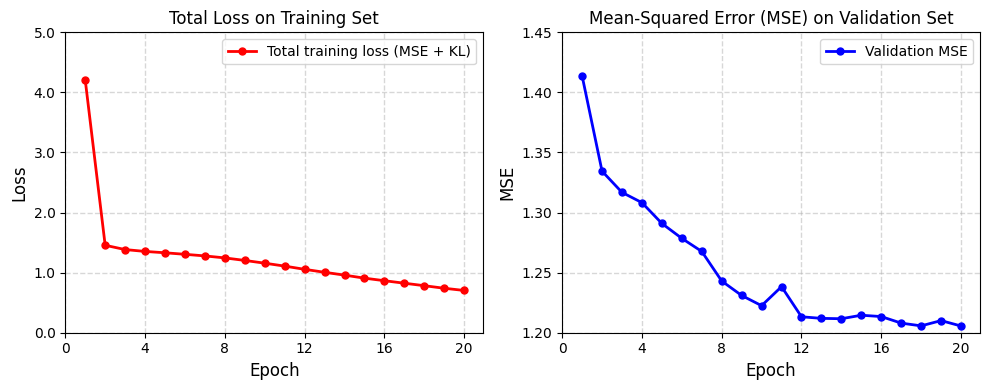

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot the training loss.
axes[0].plot(history['epoch'], history['train_loss'], color=(1, 0, 0), linewidth=2, marker='.', markersize=10, label='Total training loss (MSE + KL)')
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[0].xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].set_ylim(0, 5)
axes[0].set_xticks(range(0, 21, 4))
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Total Loss on Training Set')
axes[0].legend(frameon=True, fontsize=10, loc='upper right')
axes[0].grid(True, linestyle='--', linewidth=1, alpha=0.5)

# Plot the validation MSE.
axes[1].plot(history['epoch'], history['val_mse'], color=(0, 0, 1), linewidth=2, marker='.', markersize=10, label='Validation MSE')
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axes[1].xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[1].set_ylim(1.20, 1.45)
axes[1].set_xticks(range(0, 21, 4))
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE', fontsize=12)
axes[1].set_title('Mean-Squared Error (MSE) on Validation Set')
axes[1].legend(frameon=True, fontsize=10, loc='upper right')
axes[1].grid(True, linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('plot_loss_curve.pdf')
plt.show()

files.download('plot_loss_curve.pdf')


5.2 Statistic analysis: Model performance on item groups with different popularities

In [ ]:
# Statistics on the item popularity from the training set.
item_popularity = train_set['book_id'].value_counts().to_dict()

test_analysis = test_set.copy().reset_index(drop=True)
test_analysis['popularity'] = test_analysis['book_id'].map(item_popularity).fillna(0)
test_analysis['pop_rank'] = test_analysis['popularity'].rank(method='first')

group_labels = ['Group 1 (Least Popular)', 'Group 2', 'Group 3', 'Group 4', 'Group 5 (Most Popular)']
test_analysis['pop_group'] = pd.qcut(test_analysis['pop_rank'], q=5, labels=group_labels)


In [ ]:
# Calculate the testing MSE on each group.
group_mse = []

for g in group_labels:
    idx = test_analysis.index[test_analysis['pop_group'] == g].to_numpy()

    group_dataset = data_builder(test_user_idx[idx],
                                 test_item_idx[idx],
                                 X_test_text[idx],
                                 test_ratings[idx])

    group_loader = DataLoader(group_dataset, batch_size=BatchSize, shuffle=False)

    mse = evaluate_model(model, group_loader, 20)
    group_mse.append(mse)

group_stats_item = pd.DataFrame({'group': group_labels,
                                 'mse': group_mse,
                                 'count': [np.sum(test_analysis['pop_group'] == g) for g in group_labels]})

print("Testing MSEs on item groups with different popularities:")
display(group_stats_item)


Testing MSEs on item groups with different popularities:


,group,mse,count
0,Group 1 (Least Popular),1.295013,3092
1,Group 2,1.208921,3091
2,Group 3,1.259160,3091
3,Group 4,1.098137,3091
4,Group 5 (Most Popular),1.196989,3091


5.3 Statistic analysis: Model performance on user groups with different engagement levels

In [ ]:
# Statistics on the user activity from the training set.
user_activity = train_set['user_id'].value_counts().to_dict()

test_analysis = test_set.copy().reset_index(drop=True)
test_analysis['activity'] = test_analysis['user_id'].map(user_activity).fillna(0)
test_analysis['activity_rank'] = test_analysis['activity'].rank(method='first')

group_labels = ['Group 1 (Least Active)', 'Group 2', 'Group 3', 'Group 4', 'Group 5 (Most Active)']
test_analysis['activity_group'] = pd.qcut(test_analysis['activity_rank'], q=5, labels=group_labels)


In [ ]:
# Calculate the testing MSE on each group.
group_mse = []

for g in group_labels:
    idx = test_analysis.index[test_analysis['activity_group'] == g].to_numpy()

    group_dataset = data_builder(test_user_idx[idx],
                                 test_item_idx[idx],
                                 X_test_text[idx],
                                 test_ratings[idx])

    group_loader = DataLoader(group_dataset, batch_size=BatchSize, shuffle=False)

    mse = evaluate_model(model, group_loader, 20)
    group_mse.append(mse)

group_stats_user = pd.DataFrame({'group': group_labels,
                            'mse': group_mse,
                            'count': [np.sum(test_analysis['activity_group'] == g) for g in group_labels]})

print("Testing MSEs on user groups with different engagement levels:")
display(group_stats_user)


Testing MSEs on user groups with different engagement levels:


,group,mse,count
0,Group 1 (Least Active),1.369374,3092
1,Group 2,1.295237,3091
2,Group 3,1.157971,3091
3,Group 4,1.211657,3091
4,Group 5 (Most Active),1.006923,3091


5.4 Plot statistic analysis results

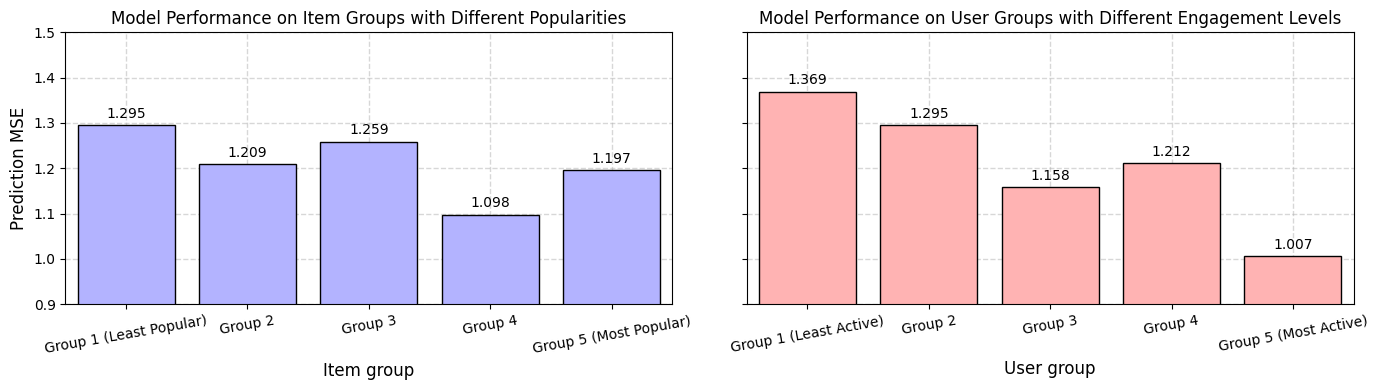

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Data preparation.
item_data = pd.Series(
    group_stats_item['mse'].values,
    index=group_stats_item['group']
)

user_data = pd.Series(
    group_stats_user['mse'].values,
    index=group_stats_user['group']
)

# Plot the results.
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# Plot the MSEs on item groups with different popularities
ax = item_data.plot(ax=axes[0], kind='bar', width=0.8, color=(0.7, 0.7, 1), edgecolor=(0, 0, 0), linewidth=1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=10, padding=3)

ax.set_ylim(0.9, 1.5)
ax.set_xlim(-0.5, len(item_data) - 0.5)
ax.tick_params(axis='x', labelrotation=10, labelsize=10)
ax.tick_params(axis='y', labelrotation=0, labelsize=10)
ax.set_xlabel('Item group', fontsize=12)
ax.set_ylabel('Prediction MSE', fontsize=12)
ax.set_title('Model Performance on Item Groups with Different Popularities', fontsize=12)
ax.grid(True, linestyle='--', linewidth=1, alpha=0.5)
ax.set_axisbelow(True)

# Plot the MSEs on user groups with different engagement levels.
ax = user_data.plot(ax=axes[1], kind='bar', width=0.8, color=(1, 0.7, 0.7), edgecolor=(0, 0, 0), linewidth=1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=10, padding=3)

ax.set_ylim(0.9, 1.5)
ax.set_xlim(-0.5, len(user_data) - 0.5)
ax.tick_params(axis='x', labelrotation=10, labelsize=10)
ax.tick_params(axis='y', labelrotation=0, labelsize=10)
ax.set_xlabel('User group', fontsize=12)
ax.set_ylabel('Testing MSE', fontsize=12)
ax.set_title('Model Performance on User Groups with Different Engagement Levels', fontsize=12)
ax.grid(True, linestyle='--', linewidth=1, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('plot_statistic_analysis.pdf')
plt.show()

files.download('plot_mse_item_user_subplots.pdf')
